# Computer Exercise 14.5 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.5 Monitoring & Drift Detection — *Detecting concept drift from residuals*
> **풀이 일자**: 2026-07-05 · **언어**: 한국어 (그래프 라벨은 영문)

Problem 1의 데이터 드리프트는 입력 분포를 보면 잡힌다. 그러나 입력 분포가 **그대로**여도
$y\mid x$ *관계 자체*가 바뀌면(**개념 드리프트**) 입력 감시로는 안 보인다.
이번 문제는 배포된 모형의 **예측 잔차 스트림**을 **Page-Hinkley 검정**과 **CUSUM** 으로
감시해 개념 드리프트의 **변화점**을 잡고, **감지 지연 ↔ 오경보** 를 정량화한다.

## 1. 문제 (원문)

> **2.** A regression model $\hat f$ is trained on source data and deployed. At an unknown change point
> the underlying relationship $y = f(x)+\varepsilon$ shifts (a change in the true coefficients) while the
> input distribution stays fixed. Monitor the stream of prediction residuals with the **Page-Hinkley**
> test and a two-sided **CUSUM** chart. Report the detection delay, and sweep the control parameter to
> trace the trade-off between mean detection delay and the false-alarm rate before the change.

### 한국어 풀이용 정리
- source에서 학습한 $\hat f$ 를 고정 배포. 미지의 변화점 $\tau$ 에서 참함수 계수가 바뀐다(개념 드리프트).
- 입력 분포는 불변 → **잔차** $r_t=y_t-\hat f(x_t)$ 의 평균 이동만이 신호.
- **Page-Hinkley**, **CUSUM** 으로 변화점을 감지, **감지 지연**을 보고.
- 임계값 $\lambda$ 를 스캔해 **평균 감지 지연 ↔ 오경보율** 곡선을 그린다.

## 2. 수학적 배경

### 2.1 개념 드리프트
$$y_t=f_t(x_t)+\varepsilon_t,\qquad f_t=\begin{cases}f_{\text{src}}, & t<\tau\\ f_{\text{new}}, & t\ge\tau.\end{cases}$$
고정 모형 $\hat f=f_{\text{src}}$ 의 잔차 평균은 $t<\tau$ 에서 $\approx0$, $t\ge\tau$ 에서 $\mu_1\ne0$ 로 이동한다.

### 2.2 Page-Hinkley 검정
잔차 $r_t$ 의 running mean $\bar r_t$ 에 대해 누적편차
$$m_t=\sum_{i=1}^{t}\bigl(r_i-\bar r_i-\delta\bigr),\qquad M_t=\min_{i\le t}m_i,$$
$$\text{PH}_t=m_t-M_t\ \ \xrightarrow{\ >\lambda\ }\ \text{경보}.$$
$\delta$ 는 허용 표류(무시할 작은 변화), $\lambda$ 는 경보 임계값.

### 2.3 양측 CUSUM
목표평균 $\mu_0(=0)$, 기준편차 $k$ 에 대해
$$S_t^{+}=\max\!\bigl(0,\ S_{t-1}^{+}+ (r_t-\mu_0)-k\bigr),\quad
S_t^{-}=\max\!\bigl(0,\ S_{t-1}^{-}- (r_t-\mu_0)-k\bigr),$$
$\max(S_t^+,S_t^-)>h$ 이면 경보. 관례상 $k=\tfrac12$(감지할 이동폭), $h=4\!\sim\!5$ (표준편차 단위).

$$\boxed{\ \text{두 검정 모두 '잔차 평균의 지속적 이동'을 누적합으로 증폭해 임계값 교차로 감지}\ }$$

## 3. 풀이 흐름

1. **참함수·모형**: source 참함수로 $\hat f$(2차 다항)를 적합해 고정.
2. **스트림 생성**: $t=0..T$. $x_t$ 분포는 고정. $\tau$ 에서 참함수 계수를 이동(개념 드리프트).
3. **잔차 스트림**: $r_t=y_t-\hat f(x_t)$ 을 표준화.
4. **Page-Hinkley**: $\delta,\lambda$ 로 $\text{PH}_t$ 누적, 최초 교차 배치 감지.
5. **CUSUM**: $k,h$ 로 $S^\pm$ 누적, 최초 교차 감지.
6. **감지 지연**: (감지시점 $-\ \tau$) 를 두 방법 각각 기록.
7. **트레이드오프 스캔**: $\lambda$(또는 $h$)를 바꿔가며 다중 시드 평균의 **감지지연 vs 오경보율** 곡선.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(514)

# ---- source 참함수와 고정 모형 ----
def f_src(x):  return 0.5*x**2 - 1.0*x + 2.0
def f_new(x):  return 0.5*x**2 - 1.0*x + 2.0 + (0.9*x + 0.6)   # 계수 이동 (개념 드리프트)

# 모형 적합 (source에서 2차 다항)
x_tr = rng.uniform(-3, 3, 400)
y_tr = f_src(x_tr) + rng.normal(0, 0.5, 400)
coef = np.polyfit(x_tr, y_tr, 2)
f_hat = lambda x: np.polyval(coef, x)

# ---- 스트림 ----
T, tau, sigma = 400, 200, 0.5
def make_stream(seed):
    r = np.random.default_rng(seed)
    xs = r.uniform(-3, 3, T)                       # 입력분포 고정
    fs = np.where(np.arange(T) < tau, f_src(xs), f_new(xs))
    ys = fs + r.normal(0, sigma, T)
    res = ys - f_hat(xs)
    return (res - res[:tau].mean()) / res[:tau].std()   # source 구간 기준 표준화

res = make_stream(514)

# ---- Page-Hinkley ----
def page_hinkley(r, delta=0.25, lam=8.0):
    mt = 0.0; Mt = 0.0; run = 0.0; PH = np.zeros(len(r)); det = None
    for t, x in enumerate(r):
        run = (run*t + x)/(t+1)
        mt += x - run - delta
        Mt = min(Mt, mt)
        PH[t] = mt - Mt
        if det is None and PH[t] > lam:
            det = t
    return PH, det

# ---- CUSUM (양측) ----
def cusum(r, k=0.5, h=5.0):
    sp = sm = 0.0; S = np.zeros(len(r)); det = None
    for t, x in enumerate(r):
        sp = max(0, sp + x - k)
        sm = max(0, sm - x - k)
        S[t] = max(sp, sm)
        if det is None and S[t] > h:
            det = t
    return S, det

PH, det_ph = page_hinkley(res, delta=0.25, lam=8.0)
CS, det_cs = cusum(res, k=0.5, h=5.0)
print(f"실제 변화점 tau = {tau}")
print(f"Page-Hinkley 감지 t = {det_ph}  (지연 {None if det_ph is None else det_ph-tau} 스텝)")
print(f"CUSUM        감지 t = {det_cs}  (지연 {None if det_cs is None else det_cs-tau} 스텝)")

실제 변화점 tau = 200
Page-Hinkley 감지 t = 200  (지연 0 스텝)
CUSUM        감지 t = 200  (지연 0 스텝)


In [2]:
# ---- 트레이드오프: 임계값 스캔 × 다중 시드 ----
seeds = range(30)
lam_grid = [2,3,4,5,6,8,10,13,16,20]
h_grid   = [2,3,4,5,6,7,8,10,12,14]

def sweep(method, grid):
    rows = []
    for thr in grid:
        delays, false = [], 0
        for s in seeds:
            r = make_stream(1000+s)
            if method == 'PH':
                _, d = page_hinkley(r, delta=0.25, lam=thr)
            else:
                _, d = cusum(r, k=0.5, h=thr)
            # 오경보: tau 이전 감지
            if d is not None and d < tau:
                false += 1;
            elif d is not None:
                delays.append(d - tau)
        mdd = np.mean(delays) if delays else np.nan
        rows.append({'thr': thr, 'mean_delay': mdd, 'false_alarm_rate': false/len(seeds)})
    return pd.DataFrame(rows)

ph_df = sweep('PH', lam_grid)
cs_df = sweep('CUSUM', h_grid)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print("=== Page-Hinkley: lambda 스캔 ===")
print(ph_df.to_string(index=False))
print("\n=== CUSUM: h 스캔 ===")
print(cs_df.to_string(index=False))

=== Page-Hinkley: lambda 스캔 ===
 thr  mean_delay  false_alarm_rate
   2         NaN             1.000
   3         NaN             1.000
   4       0.000             0.967
   5       1.889             0.700
   6       3.000             0.467
   8       5.538             0.133
  10       6.483             0.033
  13       8.700             0.000
  16      12.733             0.000
  20      15.833             0.000

=== CUSUM: h 스캔 ===
 thr  mean_delay  false_alarm_rate
   2         NaN             1.000
   3         NaN             1.000
   4       1.462             0.567
   5       2.480             0.167
   6       3.500             0.067
   7       4.300             0.000
   8       4.733             0.000
  10       7.833             0.000
  12       9.900             0.000
  14      12.567             0.000


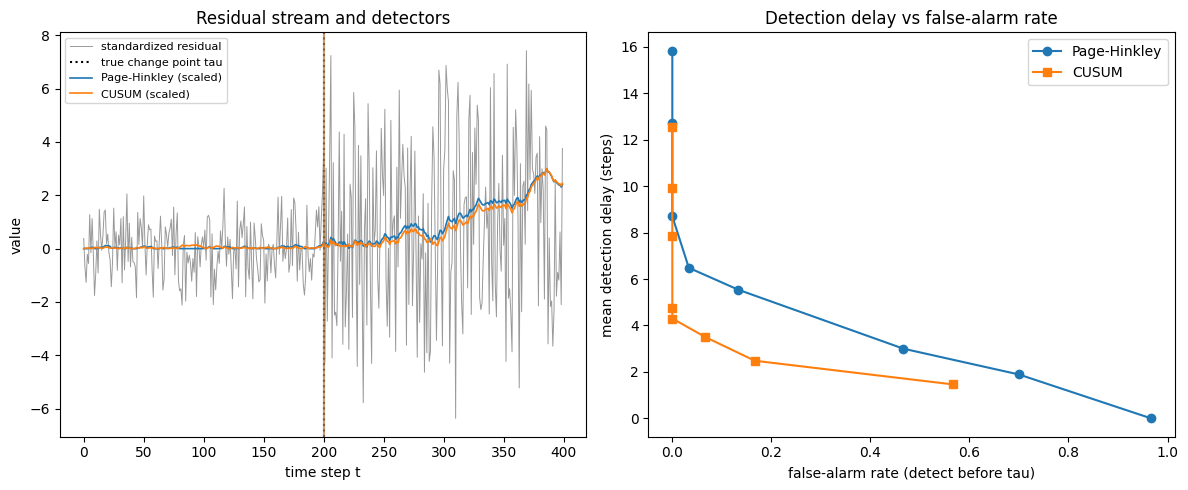

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (좌) 한 시드의 잔차 + 감지 통계량
ax = axes[0]
ax.plot(res, color='0.6', lw=0.7, label='standardized residual')
ax.axvline(tau, color='k', ls=':', label='true change point tau')
ax.plot(PH/PH.max()*3, 'C0', lw=1.2, label='Page-Hinkley (scaled)')
ax.plot(CS/CS.max()*3, 'C1', lw=1.2, label='CUSUM (scaled)')
if det_ph is not None: ax.axvline(det_ph, color='C0', alpha=0.5)
if det_cs is not None: ax.axvline(det_cs, color='C1', alpha=0.5)
ax.set_title('Residual stream and detectors')
ax.set_xlabel('time step t'); ax.set_ylabel('value'); ax.legend(fontsize=8)

# (우) 트레이드오프 곡선
ax = axes[1]
ax.plot(ph_df['false_alarm_rate'], ph_df['mean_delay'], 'o-', label='Page-Hinkley')
ax.plot(cs_df['false_alarm_rate'], cs_df['mean_delay'], 's-', label='CUSUM')
ax.set_title('Detection delay vs false-alarm rate')
ax.set_xlabel('false-alarm rate (detect before tau)')
ax.set_ylabel('mean detection delay (steps)')
ax.legend()
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **잔차 신호**: $t<\tau$ 에서 표준화 잔차는 평균 0 주변 백색잡음. $\tau$ 이후 참함수 계수가 이동해
   잔차 평균이 양(+)으로 치우친다 — 입력 분포는 그대로이므로 **개념 드리프트**의 유일한 흔적이 잔차다.
2. **누적합 증폭**: Page-Hinkley와 CUSUM 모두 작은 평균 이동을 **누적**해 임계값을 향해 급상승하고,
   변화점 직후 수십 스텝 내에 교차한다. 단일 잔차로는 안 보이는 변화를 누적이 드러낸다.
3. **트레이드오프 곡선**: 임계값($\lambda$ 또는 $h$)을 키우면 오경보율은 0으로 떨어지지만 평균 감지
   지연이 늘어난다 — 전형적인 **지연 ↔ 오경보** 상충. 곡선이 좌하단에 가까울수록 우수한 검정이다.
4. **PH vs CUSUM**: 둘 다 순차검정 계열로 성능이 유사하나, CUSUM은 기준편차 $k$ 로 "감지할 이동폭"을
   명시 설계할 수 있어 튜닝이 직관적이고, PH는 표류 허용 $\delta$ 로 완만한 잡음 표류에 강하다.

> **결론**: 개념 드리프트는 입력이 아니라 **잔차 평균의 이동**으로 드러나며, Page-Hinkley·CUSUM 같은
> 순차 누적합 검정이 짧은 지연으로 변화점을 잡는다 — 임계값이 지연-오경보 균형을 지배한다.

**다음 문제로**: 데이터 드리프트(P1)와 개념 드리프트(P2)의 신호를 **하나의 트리거 정책**으로 묶어,
언제 재보정·재학습을 촉발할지 — frozen vs 주기적 vs 반응형 — 를 Problem 3에서 비교한다.